In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx

# Lab Work

In [6]:
data = pd.read_csv('Groceries data.csv')
data

,Member_number,Date,itemDescription,year,month,day,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,21,1
1,2552,2015-05-01,whole milk,2015,5,1,4
2,2300,2015-09-19,pip fruit,2015,9,19,5
3,1187,2015-12-12,other vegetables,2015,12,12,5
4,3037,2015-01-02,whole milk,2015,1,2,4
...,...,...,...,...,...,...,...
38760,4471,2014-08-10,sliced cheese,2014,8,10,6
38761,2022,2014-02-23,candy,2014,2,23,6
38762,1097,2014-04-16,cake bar,2014,4,16,2
38763,1510,2014-03-12,fruit/vegetable juice,2014,3,12,2


In [7]:
transactions = data.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index(name='items')
data = transactions['items'].tolist()
te = TransactionEncoder()
te_ary = te.fit(data).transform(data)
df = pd.DataFrame(te_ary, columns=te.columns_)
print(df)

       Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                      False     False             False             False   
1                      False     False             False             False   
2                      False     False             False             False   
3                      False     False             False             False   
4                      False     False             False             False   
...                      ...       ...               ...               ...   
14958                  False     False             False             False   
14959                  False     False             False             False   
14960                  False     False             False             False   
14961                  False     False             False             False   
14962                  False     False             False             False   

       baby cosmetics   bags  baking powder  bathroom cleaner  

In [8]:
freq_itemsets = fpgrowth(df, min_support=0.005, use_colnames=True)
print(freq_itemsets)

      support                     itemsets
0    0.157923                 (whole milk)
1    0.051728                     (pastry)
2    0.018780                (salty snack)
3    0.085879                     (yogurt)
4    0.060349                    (sausage)
..        ...                          ...
121  0.007151   (bottled beer, whole milk)
122  0.005280  (whole milk, domestic eggs)
123  0.005614     (whole milk, newspapers)
124  0.007151   (whole milk, citrus fruit)
125  0.005012           (whole milk, pork)

[126 rows x 2 columns]


In [20]:
rules = association_rules(freq_itemsets, metric="support", min_threshold=0.008)
print(rules)

           antecedents         consequents  antecedent support  \
0         (whole milk)            (yogurt)            0.157923   
1             (yogurt)        (whole milk)            0.085879   
2             (yogurt)  (other vegetables)            0.085879   
3   (other vegetables)            (yogurt)            0.122101   
4         (whole milk)           (sausage)            0.157923   
5            (sausage)        (whole milk)            0.060349   
6         (whole milk)              (soda)            0.157923   
7               (soda)        (whole milk)            0.097106   
8               (soda)  (other vegetables)            0.097106   
9   (other vegetables)              (soda)            0.122101   
10              (soda)        (rolls/buns)            0.097106   
11        (rolls/buns)              (soda)            0.110005   
12        (whole milk)        (rolls/buns)            0.157923   
13        (rolls/buns)        (whole milk)            0.110005   
14        

In [21]:
G = nx.DiGraph()

In [22]:
for _, row in rules.iterrows():
  lhs = tuple(row["antecedents"])
  rhs = tuple(row["consequents"])

  prev = "NULL"

  for item in lhs:
    if not G.has_edge(prev, item):
      G.add_edge(prev, item)
    prev = item

  for item in rhs:
    if not G.has_edge(prev, item):
      G.add_edge(prev, item)
    prev = item

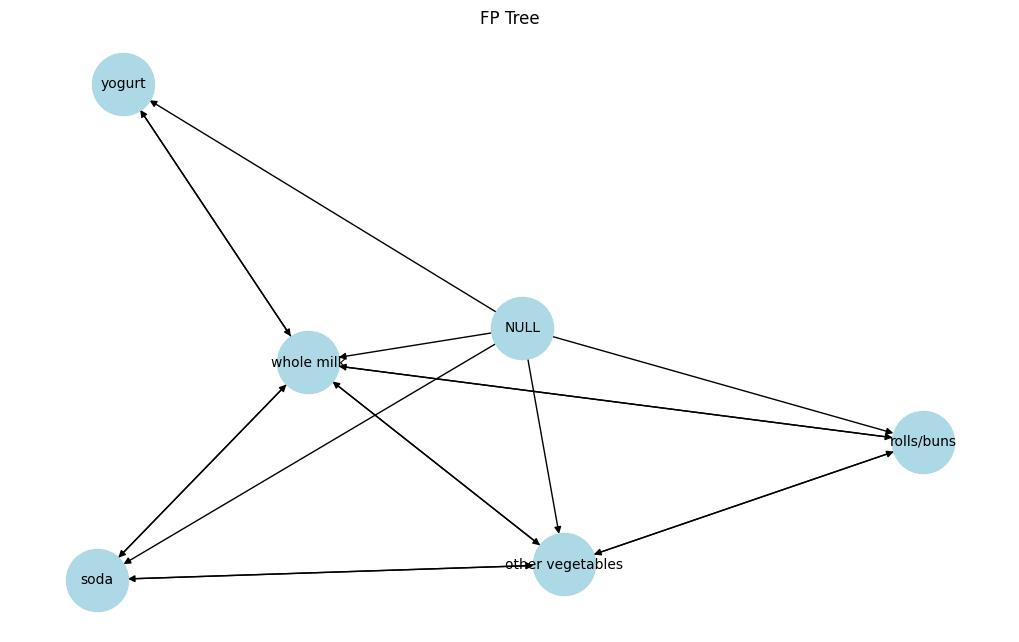

In [19]:
pos = nx.spring_layout(G) 
plt.figure(figsize=(10,6))
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_size=10, arrows=True)
plt.title("FP Tree")
plt.show()
